# Reproducing *Optimizing YOLOv8 for Parking Space Detection* — Kaggle

Trains and evaluates all five YOLOv8 variants from
[arXiv:2505.17364](https://arxiv.org/abs/2505.17364) on PKLot, then diffs your numbers against
the paper's Table 3 (accuracy) and Table 4 (complexity).

**Variants:** `yolov8n` (baseline) · `resnet18` · `vgg16` · `efficientnetv2` · `ghostp2`

---

## Before you run anything — notebook settings

Open the **⚙ Settings** panel on the right:

| Setting | Value |
|---|---|
| **Accelerator** | **GPU T4 x2** |
| **Internet** | **On** — needed for `pip install` and the dataset download |
| Persistence | Files only |

> **Do not pick P100.** Kaggle still offers it, but it is Pascal (sm_60) and current PyTorch
> builds only support sm_70 and newer — every CUDA kernel fails. T4 is Turing (sm_75) and works.

**Internet requires a phone-verified Kaggle account.** Without it, `pip install ultralytics` and
the Roboflow download both fail. Verify at Settings → Phone Verification.

---

## The 12-hour problem — read this before starting

Kaggle caps a session at **12 hours** and gives you **~30 GPU-hours per week**. A full 5-model run
takes roughly **10 hours** on a T4. That is too close to the cap - if anything runs slow you lose the session.

**Do it in three commits instead.** Edit `MODELS_TO_RUN` in the config cell, then
**Save Version → Save & Run All (Commit)** each time:

| Commit | `MODELS_TO_RUN` | ~T4 time |
|---|---|---|
| 1 | `["yolov8n", "ghostp2"]` | ~2.7 h |
| 2 | `["vgg16", "efficientnetv2"]` | ~4.1 h |
| 3 | `["resnet18"]` | ~3.3 h |

After each commit finishes, **add that version's output as a data source for the next one**
(→ *Add Input* → *Notebook Output* → pick this notebook). Section 2 below detects those saved
runs and skips models that are already trained. Full instructions in `RUN_STEPS.md`.

Use **Save & Run All (Commit)**, not the interactive session — a commit runs headless in the
background, so you can close the browser and it keeps going.

---

## Just want to check the paper's models?

Run **Sections 0 → 4 only**. About 5 minutes, no training, no GPU quota burned. Section 4
rebuilds every model and diffs params/layers/GFLOPs against the paper's Table 4 — that check is
what exposed the biggest problem in the authors' repo.

---

### Using both T4s

`Accelerator: GPU T4 x2` gives you two cards. The training cell uses both by default
(`USE_BOTH_GPUS = True`), which cuts the full run from **~10 h to ~6 h**.

This does **not** change the experiment. Ultralytics splits the batch across GPUs
(`batch // world_size`), so `batch=16` becomes 8 per GPU and the effective batch is still 16 —
gradient accumulation and weight-decay scaling are computed from the total. Identical maths,
fewer wall-clock hours.

DDP inside a notebook is the one fragile part, so the training cell catches a DDP failure,
discards the partial run, and retries that variant on a single GPU automatically. Run the smoke
test first — it exercises the same DDP path in ~15 minutes.


## 0 · Environment

In [39]:
import os, subprocess, sys, time
from pathlib import Path

print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                      "--format=csv,noheader"], capture_output=True, text=True).stdout or
      "!! No GPU. Settings -> Accelerator -> GPU T4 x2, then re-run.")

import torch
print(f"torch          : {torch.__version__}  (CUDA {torch.version.cuda})")
print(f"cuda available : {torch.cuda.is_available()}")

GPU, READY = None, False
if torch.cuda.is_available():
    GPU = torch.cuda.get_device_name(0)
    cap = torch.cuda.get_device_capability(0)
    sm = f"sm_{cap[0]}{cap[1]}"
    arches = torch.cuda.get_arch_list()
    print(f"gpu            : {GPU} x{torch.cuda.device_count()}")
    print(f"compute cap    : {cap[0]}.{cap[1]}  ({sm})")
    print(f"vram           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"torch supports : {', '.join(arches)}")

    if arches and sm not in arches:
        # This is the P100 trap: Kaggle still offers it, but recent PyTorch dropped Pascal.
        print(f"\n{'!' * 74}")
        print(f"  {GPU} is {sm}, which this PyTorch build does NOT support.")
        print(f"  Nothing will train - every CUDA kernel launch will fail.")
        print(f"\n  FIX: Settings panel -> Accelerator -> **GPU T4 x2** -> Run All again.")
        print(f"       (T4 is Turing/sm_75, which is supported. P100 is Pascal/sm_60.)")
        print(f"{'!' * 74}")
    else:
        try:
            a = torch.randn(512, 512, device="cuda"); (a @ a).sum().item()
            torch.cuda.synchronize()
            print("matmul test    : OK")
            READY = True
        except Exception as e:
            print(f"\n!! GPU matmul FAILED: {e}")
else:
    print("\n!! NO GPU. Settings -> Accelerator -> GPU T4 x2, then Run All again.")

try:
    import urllib.request
    urllib.request.urlopen("https://pypi.org", timeout=10)
    print("internet       : ON")
except Exception:
    print("\n!! INTERNET IS OFF. Settings -> Internet -> On (needs phone verification).")

print("\n" + ("PASS - ready to train." if READY else "FAIL - fix the above before training."))

Tesla T4, 15360 MiB, 580.159.04
Tesla T4, 15360 MiB, 580.159.04

torch          : 2.10.0+cu128  (CUDA 12.8)
cuda available : True
gpu            : Tesla T4 x2
compute cap    : 7.5  (sm_75)
vram           : 15.6 GB
torch supports : sm_70, sm_75, sm_80, sm_86, sm_90, sm_100, sm_120
matmul test    : OK
internet       : ON

PASS - ready to train.


In [40]:
# Kaggle does not preinstall ultralytics. Pinned to match the paper's 8.3.x behaviour.
ULTRALYTICS_VERSION = "8.3.100"   # "" for latest

spec = f"ultralytics=={ULTRALYTICS_VERSION}" if ULTRALYTICS_VERSION else "ultralytics"
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", spec, "roboflow"],
                   capture_output=True, text=True)
if r.returncode:
    print(f"pin failed, falling back to latest\n{r.stderr[-600:]}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics", "roboflow"],
                   check=True)

# Keep Ultralytics' config out of the read-only home dir
os.environ["YOLO_CONFIG_DIR"] = "/kaggle/working/.ultralytics"
Path(os.environ["YOLO_CONFIG_DIR"]).mkdir(parents=True, exist_ok=True)

import ultralytics
print("ultralytics", ultralytics.__version__)

ultralytics 8.3.100


## 1 · Configuration

The only cell you normally need to edit.

In [41]:
# ----- which variants to train THIS session ---------------------------------------------
# Three commits, editing this line each time, keeps every session well inside the 12 h cap:
#   commit 1: ["yolov8n", "ghostp2"]
#   commit 2: ["vgg16", "efficientnetv2"]
#   commit 3: ["resnet18"]
MODELS_TO_RUN = ["yolov8n", "resnet18", "vgg16", "efficientnetv2", "ghostp2"]

QUICK_TEST = False          # True -> 1 epoch on 5% of the data (~10 min). Set False for real.

# ----- training hyperparameters (paper Table 2 + the authors' logged args.yaml) ----------
EPOCHS    = 20
BATCH     = 16
IMGSZ     = 640
SEED      = 0
# ----- multi-GPU ---------------------------------------------------------------------------
# Kaggle's "GPU T4 x2" gives two cards. Ultralytics runs DDP and does
#     per_gpu_batch = batch // world_size
# so batch=16 becomes 8 per GPU and the EFFECTIVE batch is still 16. `accumulate` and the
# weight-decay scaling are computed from the total too, so the optimizer maths is identical to
# a single-GPU run - this is a pure speedup, not a change to the experiment.
USE_BOTH_GPUS = True                       # set False to force a single GPU

N_GPU  = torch.cuda.device_count()
DEVICE = [0, 1] if (USE_BOTH_GPUS and N_GPU >= 2) else 0
DDP    = isinstance(DEVICE, list)

# Ultralytics clamps workers to os.cpu_count() // n_gpu. Kaggle gives 4 vCPUs, so with 2 GPUs
# this lands at 2 per GPU = 4 total, which is what those 4 cores can actually feed.
WORKERS = 2
OPTIMIZER = "auto"         # -> AdamW(lr=0.001667, momentum=0.9), what the paper reports

# ----- paths -----------------------------------------------------------------------------
PROJECT   = Path("/kaggle/working/runs")    # saved as notebook output (20 GB cap)
DATA_ROOT = Path("/kaggle/temp/PKLot")      # scratch - NOT saved, keeps output small

# ----- dataset ---------------------------------------------------------------------------
# "roboflow" downloads PKLot v2-640, the exact export the authors used. Needs Internet ON.
# "kaggle"   uses a PKLot dataset you've attached via Add Input.
DATASET_MODE      = "roboflow"
ROBOFLOW_API_KEY  = "6Dd1ht79GoYtWivDLrDt"                      # <-- free key from roboflow.com
KAGGLE_DATASET_DIR = "/kaggle/input"        # searched recursively for data.yaml

RENAME_CLASSES_TO_EO = True   # authors renamed space-empty/space-occupied to e/o

ALL_MODELS = ["yolov8n", "resnet18", "vgg16", "efficientnetv2", "ghostp2"]
DISPLAY_NAME = {
    "yolov8n": "YOLOv8n", "resnet18": "YOLO-ResNet-18", "vgg16": "YOLO-VGG16",
    "efficientnetv2": "YOLO-EfficientNetV2", "ghostp2": "YOLO-Ghost-P2",
}
# Authors' A100 wall-clock per model, seconds (their results.csv `time` column)
A100_SECONDS = {"yolov8n": 1274, "ghostp2": 2012, "vgg16": 2447,
                "efficientnetv2": 2663, "resnet18": 4146}
# Rough slowdown vs A100 on this workload
SLOWDOWN = {"A100": 1.0, "L4": 2.0, "V100": 1.8, "T4": 2.9}   # P100 unusable here

factor = next((v for k, v in SLOWDOWN.items() if GPU and k in GPU), 2.5)
_mg = 1.7 if DDP else 1.0        # measured DDP scaling on 2x T4 / 4 vCPU
est_h = sum(A100_SECONDS[k] for k in MODELS_TO_RUN) * factor / _mg / 3600

PROJECT.mkdir(parents=True, exist_ok=True)
FRACTION   = 0.05 if QUICK_TEST else 1.0
RUN_EPOCHS = 1    if QUICK_TEST else EPOCHS

print(f"models   : {MODELS_TO_RUN}")
print(f"mode     : {'QUICK TEST (1 epoch, 5% data)' if QUICK_TEST else f'FULL RUN ({EPOCHS} epochs)'}")
print(f"gpu      : {GPU} x{N_GPU}  (~{factor}x slower than the paper's A100)")
print(f"devices  : {DEVICE}   {'DDP across both T4s' if DDP else 'single GPU'}")
print(f"estimate : ~{est_h:.1f} h for this session" + ("  [12 h session cap!]" if est_h > 9 else ""))
if est_h > 9 and not QUICK_TEST:
    print("\n  !! Too close to the 12 h cap. Split MODELS_TO_RUN across commits - see the header.")

models   : ['yolov8n', 'resnet18', 'vgg16', 'efficientnetv2', 'ghostp2']
mode     : FULL RUN (20 epochs)
gpu      : Tesla T4 x2  (~2.9x slower than the paper's A100)
devices  : [0, 1]   DDP across both T4s
estimate : ~5.9 h for this session


## 2 · Restore previously-trained models

Kaggle's persistence trick: a finished commit's `/kaggle/working` becomes that version's
**output**, and you can attach it to the next version as an input.

This cell scans `/kaggle/input/` for runs saved by an earlier commit and copies them in, so those
models get skipped instead of retrained. Harmless on your first run — it just finds nothing.

**To chain sessions:** after a commit finishes → *Add Input* → *Notebook Output* → select this
notebook's completed version.

In [42]:
import shutil

restored = []
for best in Path("/kaggle/input").glob("*/runs/*_train/weights/best.pt"):
    run_dir = best.parent.parent                  # .../<key>_train
    dest = PROJECT / run_dir.name
    if dest.exists():
        continue
    shutil.copytree(run_dir, dest)
    restored.append(run_dir.name.replace("_train", ""))

if restored:
    print(f"restored from a previous commit: {', '.join(sorted(restored))}")
    print("these will be skipped during training")
else:
    print("no previous runs found - training everything in MODELS_TO_RUN from scratch")

no previous runs found - training everything in MODELS_TO_RUN from scratch


## 3 · Dataset

PKLot, Roboflow export **v2 ("640")** — 12,416 images, 2 classes, 70/20/10 split, already at
640×640. The exact export the authors used (`PKLot.v2-640.yolov8.zip`), ~1.5 GB.

Downloaded to `/kaggle/temp/` rather than `/kaggle/working/` so it doesn't eat into your 20 GB
output budget.

Roboflow writes *relative* paths into `data.yaml` (`../train/images`) which break under Kaggle's
directory layout, so they get rewritten to absolute.

In [43]:
import glob, yaml

import shutil

if DATASET_MODE == "roboflow":
    assert ROBOFLOW_API_KEY, "Set ROBOFLOW_API_KEY in the config cell (free at roboflow.com)."
    from roboflow import Roboflow
    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    dataset = (Roboflow(api_key=ROBOFLOW_API_KEY).workspace("brad-dwyer").project("pklot-1tros")
       .version(2).download("yolov8", location=str(DATA_ROOT)))
    search_root = Path(dataset.location)
elif DATASET_MODE == "kaggle":
    search_root = Path(KAGGLE_DATASET_DIR)
else:
    raise ValueError(DATASET_MODE)

# data.yaml from an attached Kaggle dataset is read-only, so write a fixed copy into working
candidates = [p for p in sorted(search_root.rglob("data.yaml")) if "runs" not in p.parts]
assert candidates, f"no data.yaml under {search_root}"
src = candidates[0]
base = src.parent
d = yaml.safe_load(src.read_text())

for split, folders in [("train", ["train"]), ("val", ["valid", "val"]), ("test", ["test"])]:
    found = next((base / f / "images" for f in folders if (base / f / "images").is_dir()), None)
    assert found, f"missing image folder for split {split!r} under {base}"
    d[split] = str(found.resolve())
d.pop("path", None)

names = d.get("names")
if isinstance(names, dict):
    names = [names[k] for k in sorted(names)]
assert len(names) == 2, f"expected 2 classes, got {names}"
d["names"] = ["e", "o"] if RENAME_CLASSES_TO_EO else names
d["nc"] = 2

DATA_YAML = "/kaggle/working/data.yaml"
Path(DATA_YAML).write_text(yaml.safe_dump(d, sort_keys=False))

print(yaml.safe_dump(d, sort_keys=False))
for split in ("train", "val", "test"):
    n_img = len(glob.glob(os.path.join(d[split], "*")))
    n_lbl = len(glob.glob(os.path.join(d[split].replace("images", "labels"), "*.txt")))
    print(f"{split:5s} {n_img:6,} images  {n_lbl:6,} labels")
print("\npaper expects ~ train 8,691 / val 2,483 / test 1,242  (70/20/10 of 12,416)")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/temp/PKLot in yolov8:: 100%|██████████| 24844/24844 [00:03<00:00, 6354.07it/s] 


names:
- e
- o
nc: 2
roboflow:
  license: CC BY 4.0
  project: pklot-1tros
  url: https://universe.roboflow.com/brad-dwyer/pklot-1tros/dataset/2
  version: 2
  workspace: brad-dwyer
test: /kaggle/temp/PKLot/test/images
train: /kaggle/temp/PKLot/train/images
val: /kaggle/temp/PKLot/valid/images

train  8,691 images   8,691 labels
val    2,483 images   2,483 labels
test   1,242 images   1,242 labels

paper expects ~ train 8,691 / val 2,483 / test 1,242  (70/20/10 of 12,416)


## 4 · Model configurations

All four carry the `scales:` block that the authors' committed YAMLs are **missing**. Without it
Ultralytics silently builds the PANet neck at `depth=width=1.0` instead of `0.33/0.25`, producing
a model roughly 4× larger than the paper's Table 4 describes.

The VGG-16 config was never committed to their repo at all (their `args.yaml` points at a personal
Google Drive path) and is reconstructed here from §5.6 of the paper.

In [44]:
CFG_DIR = Path("/kaggle/working/cfg"); CFG_DIR.mkdir(parents=True, exist_ok=True)

_TV_HEAD = """
head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 2], 1, Concat, [1]]          # cat backbone P4
  - [-1, 3, C2f, [512]]                # 7
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 1], 1, Concat, [1]]          # cat backbone P3
  - [-1, 3, C2f, [256]]                # 10 (P3/8-small)
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 7], 1, Concat, [1]]          # cat head P4
  - [-1, 3, C2f, [512]]                # 13 (P4/16-medium)
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 4], 1, Concat, [1]]          # cat head P5
  - [-1, 3, C2f, [1024]]               # 16 (P5/32-large)
  - [[10, 13, 16], 1, Detect, [nc]]    # Detect(P3, P4, P5)
"""

def _tv_cfg(tv_name, c2_out, taps):
    """taps = [(channels, split_index), ...] for P3/8, P4/16, P5/32."""
    lines = "\n".join(f"  - [0, 1, Index, [{c}, {i}]]" for c, i in taps)
    return ("nc: 2\n"
            "scales:\n"
            "  n: [0.33, 0.25, 1024]\n"
            "backbone:\n"
            f'  - [-1, 1, TorchVision, [{c2_out}, "{tv_name}", "DEFAULT", True, 2, True]]\n'
            f"{lines}\n"
            "  - [-1, 1, SPPF, [1024, 5]]\n" + _TV_HEAD)

# Split indices verified against torchvision: y[0] is the input, y[i] the output of sub-module i-1.
CFGS = {
    "yolov8n-resnet18.yaml":          _tv_cfg("resnet18", 2048, [(128, 6), (256, 7), (512, 8)]),
    "yolov8n-efficientnetv2_S.yaml":  _tv_cfg("efficientnet_v2_s", 2048, [(64, 4), (160, 6), (1280, 8)]),
    "yolov8n-vgg16.yaml":             _tv_cfg("vgg16", 512, [(512, 23), (512, 30), (512, 31)]),
}

# Ghost-P2 is Ultralytics' stock config: GhostConv/C3Ghost throughout plus a 4th head at P2/4.
CFGS["yolov8n-ghost-p2.yaml"] = """nc: 2
scales:
  n: [0.33, 0.25, 1024]
backbone:
  - [-1, 1, Conv, [64, 3, 2]]            # 0-P1/2
  - [-1, 1, GhostConv, [128, 3, 2]]      # 1-P2/4
  - [-1, 3, C3Ghost, [128, True]]
  - [-1, 1, GhostConv, [256, 3, 2]]      # 3-P3/8
  - [-1, 6, C3Ghost, [256, True]]
  - [-1, 1, GhostConv, [512, 3, 2]]      # 5-P4/16
  - [-1, 6, C3Ghost, [512, True]]
  - [-1, 1, GhostConv, [1024, 3, 2]]     # 7-P5/32
  - [-1, 3, C3Ghost, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]             # 9
head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [512]]              # 12
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [256]]              # 15 (P3/8-small)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [128]]              # 18 (P2/4-xsmall)
  - [-1, 1, GhostConv, [128, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [256]]              # 21 (P3/8-small)
  - [-1, 1, GhostConv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [512]]              # 24 (P4/16-medium)
  - [-1, 1, GhostConv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C3Ghost, [1024]]             # 27 (P5/32-large)
  - [[18, 21, 24, 27], 1, Detect, [nc]]  # Detect(P2, P3, P4, P5)
"""

for fname, text in CFGS.items():
    (CFG_DIR / fname).write_text(text)

INIT = {
    "yolov8n":        "yolov8n.pt",     # baseline fine-tunes from pretrained weights
    "resnet18":       str(CFG_DIR / "yolov8n-resnet18.yaml"),
    "vgg16":          str(CFG_DIR / "yolov8n-vgg16.yaml"),
    "efficientnetv2": str(CFG_DIR / "yolov8n-efficientnetv2_S.yaml"),
    "ghostp2":        str(CFG_DIR / "yolov8n-ghost-p2.yaml"),
}
# yolov8n trains from .pt but must be *built* from yaml to count params/layers
ARCH_CFG = dict(INIT, yolov8n="yolov8n.yaml")

for f in sorted(CFG_DIR.iterdir()):
    print("wrote", f)

wrote /kaggle/working/cfg/yolov8n-efficientnetv2_S.yaml
wrote /kaggle/working/cfg/yolov8n-ghost-p2.yaml
wrote /kaggle/working/cfg/yolov8n-resnet18.yaml
wrote /kaggle/working/cfg/yolov8n-vgg16.yaml


## 5 · Architecture check — reproduces Table 4 without training

Builds each model at `nc=2`, runs a forward pass to prove the tensor shapes line up, and diffs
params / layers / GFLOPs against the paper.

**Run this before training.** A shape mismatch caught here costs seconds; the same mismatch after
three hours of training costs three hours.

Downloads ImageNet weights for the three torchvision backbones (~650 MB, VGG-16 is most of it).
They're cached and reused during training, so it isn't wasted.

In [45]:
import contextlib, gc, io
import pandas as pd
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils.torch_utils import get_flops

pd.set_option("display.width", 200)

# Paper Table 4. infer_ms is NOT comparable across rows - the paper mixes A100 and T4 timings.
PAPER_T4 = {
    "yolov8n":        dict(params_M=3.01,  layers=129, gflops=8.2,   infer_ms=0.9),
    "resnet18":       dict(params_M=13.32, layers=132, gflops=35.2,  infer_ms=9.0),
    "vgg16":          dict(params_M=17.78, layers=113, gflops=262.1, infer_ms=3.3),
    "efficientnetv2": dict(params_M=23.40, layers=564, gflops=56.4,  infer_ms=4.1),
    "ghostp2":        dict(params_M=1.60,  layers=290, gflops=8.8,   infer_ms=1.5),
}

rows = []
for key in MODELS_TO_RUN:
    with contextlib.redirect_stdout(io.StringIO()):
        m = DetectionModel(ARCH_CFG[key], nc=2, verbose=False).eval()
    with torch.no_grad():
        out = m(torch.zeros(1, 3, IMGSZ, IMGSZ))
    feats = out[1] if isinstance(out, (list, tuple)) else out
    p = PAPER_T4[key]
    rows.append({
        "model": DISPLAY_NAME[key],
        "params_M": round(sum(q.numel() for q in m.parameters()) / 1e6, 2),
        "paper_params_M": p["params_M"],
        "layers": sum(1 for _, mm in m.named_modules() if len(mm._modules) == 0),
        "paper_layers": p["layers"],
        "GFLOPs": round(get_flops(m, IMGSZ), 1), "paper_GFLOPs": p["gflops"],
        "strides": [IMGSZ // t.shape[-1] for t in feats],
    })
    del m; gc.collect()

arch = pd.DataFrame(rows)
arch["params_delta_%"] = ((arch.params_M / arch.paper_params_M - 1) * 100).round(1)
arch["GFLOPs_delta_%"] = ((arch.GFLOPs / arch.paper_GFLOPs - 1) * 100).round(1)
display(arch)

print("strides: [8,16,32] normally; [4,8,16,32] for Ghost-P2, which carries an extra P2 head.")
bad = arch[arch.layers != arch.paper_layers]
print("\nAll layer counts match the paper - configs are sound."
      if bad.empty else f"\n!! layer mismatch: {list(bad.model)}")

Overriding model.yaml nc=80 with nc=2


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]
100%|██████████| 528M/528M [00:03<00:00, 172MB/s] 
100%|██████████| 82.7M/82.7M [00:00<00:00, 185MB/s]


,model,params_M,paper_params_M,layers,paper_layers,GFLOPs,paper_GFLOPs,strides,params_delta_%,GFLOPs_delta_%
0,YOLOv8n,3.01,3.01,129,129,8.2,8.2,"[8, 16, 32]",0.0,0.0
1,YOLO-ResNet-18,13.33,13.32,132,132,35.2,35.2,"[8, 16, 32]",0.1,0.0
2,YOLO-VGG16,16.93,17.78,113,113,256.4,262.1,"[8, 16, 32]",-4.8,-2.2
3,YOLO-EfficientNetV2,23.40,23.40,564,564,56.4,56.4,"[8, 16, 32]",0.0,0.0
4,YOLO-Ghost-P2,1.61,1.60,290,290,8.8,8.8,"[4, 8, 16, 32]",0.6,0.0


strides: [8,16,32] normally; [4,8,16,32] for Ghost-P2, which carries an extra P2 head.

All layer counts match the paper - configs are sound.


## 6 · Train

Each variant trains under identical settings, exactly as the paper specifies. Everything lands in
`/kaggle/working/runs/<key>_train/`.

Models restored in Section 2 are skipped; interrupted runs resume from `last.pt`.

**Keep an eye on the clock.** Kaggle kills the session at 12 hours with no warning. If the
estimate printed in Section 1 was above ~9 h, go back and split `MODELS_TO_RUN` across commits.

In [46]:
import shutil, time, traceback
from ultralytics import YOLO

assert READY, "GPU check failed in Section 0 - set Accelerator to GPU T4 x2 and Run All again."


def _train(key, device):
    """One variant, on `device` (0 = single GPU, [0,1] = both via DDP)."""
    YOLO(INIT[key]).train(
        data=DATA_YAML, epochs=RUN_EPOCHS, batch=BATCH, imgsz=IMGSZ,
        seed=SEED, deterministic=True, workers=WORKERS, optimizer=OPTIMIZER,
        fraction=FRACTION, project=str(PROJECT), name=f"{key}_train",
        exist_ok=True, plots=True, val=True, device=device,
    )


log, t_all = {}, time.time()
mode = f"{len(DEVICE)}x GPU (DDP)" if DDP else "1x GPU"
print(f"training on {mode}  |  batch {BATCH} total"
      f"{f' = {BATCH // len(DEVICE)} per GPU' if DDP else ''}  |  workers {WORKERS}/GPU\n")

for key in MODELS_TO_RUN:
    run_dir = PROJECT / f"{key}_train"
    best, last = run_dir / "weights" / "best.pt", run_dir / "weights" / "last.pt"

    if best.exists():
        print(f"[skip] {DISPLAY_NAME[key]}: already trained")
        log[key] = "skipped"
        continue

    print(f"\n{'=' * 78}\n  TRAIN  {DISPLAY_NAME[key]}  on {mode}"
          f"   (elapsed: {(time.time() - t_all) / 3600:.1f} h)\n{'=' * 78}")
    t0 = time.time()
    try:
        if last.exists():
            print(f"resuming from {last}")
            YOLO(str(last)).train(resume=True)
        else:
            _train(key, DEVICE)
        log[key] = f"ok  {(time.time() - t0) / 60:.0f} min  ({mode})"

    except Exception:
        traceback.print_exc()
        # DDP is the fragile part - a notebook DDP launch can fail for reasons that have
        # nothing to do with the model. Don't lose the whole run over it: bin the partial
        # output and redo this one variant on a single GPU.
        if DDP:
            print(f"\n{'!' * 78}\n  Multi-GPU (DDP) failed for {DISPLAY_NAME[key]}."
                  f"\n  Retrying on a single GPU - slower, but identical results.\n{'!' * 78}")
            shutil.rmtree(run_dir, ignore_errors=True)   # partial run would confuse resume
            t0 = time.time()
            try:
                _train(key, 0)
                log[key] = f"ok  {(time.time() - t0) / 60:.0f} min  (1x GPU fallback)"
            except Exception:
                traceback.print_exc()
                log[key] = "FAILED"
        else:
            log[key] = "FAILED"

    print(f"[{key}] {log[key]}")

print(f"\n{'=' * 78}\nsession total: {(time.time() - t_all) / 3600:.2f} h")
for k, v in log.items():
    print(f"  {k:16s} {v}")

# Real measured scaling, so you can re-estimate the remaining commits.
_done = {k: v for k, v in log.items() if v.startswith("ok") and "min" in v}
if _done and DDP:
    print("\nMeasured vs the paper's A100 (their results.csv):")
    for k, v in _done.items():
        mins = float(v.split()[1])
        print(f"  {k:16s} {mins:5.0f} min   A100 {A100_SECONDS[k] / 60:5.0f} min"
              f"   ratio {mins * 60 / A100_SECONDS[k]:.2f}x")


training on 2x GPU (DDP)  |  batch 16 total = 8 per GPU  |  workers 2/GPU


  TRAIN  YOLOv8n  on 2x GPU (DDP)   (elapsed: 0.0 h)


100%|██████████| 6.25M/6.25M [00:00<00:00, 472MB/s]

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.100 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                         CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=[0, 1], workers=2, project=/kaggle/working/runs, name=yolov8n_train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=

100%|██████████| 755k/755k [00:00<00:00, 145MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all       2483     143316      0.963      0.975      0.986      0.887

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      20/20        10G     0.5973     0.4333      0.883        128        640: 100%|██████████| 544/544 [02:04<00:00,  4.39it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 156/156 [00:31<00:00,  5.02it/s]


                   all       2483     143316      0.963      0.975      0.988      0.889

20 epochs completed in 0.965 hours.
Optimizer stripped from /kaggle/working/runs/ghostp2_train/weights/last.pt, 3.7MB
Optimizer stripped from /kaggle/working/runs/ghostp2_train/weights/best.pt, 3.7MB

Validating /kaggle/working/runs/ghostp2_train/weights/best.pt...
Ultralytics 8.3.100 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                         CUDA:1 (Tesla T4, 14912MiB)
YOLOv8n-ghost-p2 summary (fused): 179 layers, 1,601,440 parameters, 0 gradients, 8.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 156/156 [00:44<00:00,  3.51it/s]


                   all       2483     143316      0.963      0.975      0.988      0.889
                     e       2062      73629      0.973      0.952      0.989      0.901
                     o       1967      69687      0.952      0.997      0.987      0.877
Speed: 0.2ms preprocess, 3.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/ghostp2_train
[ghostp2] ok  59 min  (2x GPU (DDP))

session total: 6.04 h
  yolov8n          ok  40 min  (2x GPU (DDP))
  resnet18         ok  45 min  (2x GPU (DDP))
  vgg16            ok  121 min  (2x GPU (DDP))
  efficientnetv2   ok  98 min  (2x GPU (DDP))
  ghostp2          ok  59 min  (2x GPU (DDP))

Measured vs the paper's A100 (their results.csv):
  yolov8n             40 min   A100    21 min   ratio 1.88x
  resnet18            45 min   A100    69 min   ratio 0.65x
  vgg16              121 min   A100    41 min   ratio 2.97x
  efficientnetv2      98 min   A100    44 min   ratio 2.21x
  ghostp2        

## 7 · Evaluate on the test split

`results.csv` only ever logs **validation**. The paper's Table 3 is the **test** split, from a
separate `val(split="test")` pass. This collects both, and re-times every model on this one GPU —
the paper's latency column mixes A100 and T4 runs and isn't internally comparable.

Evaluates every trained model it finds, including ones restored from earlier commits.

In [47]:
available = [k for k in ALL_MODELS if (PROJECT / f"{k}_train" / "weights" / "best.pt").exists()]
print(f"evaluating: {available}\n")

rows = []
for key in available:
    best = PROJECT / f"{key}_train" / "weights" / "best.pt"
    print(f"--- val(split='test')  {DISPLAY_NAME[key]} ---")
    r = YOLO(str(best)).val(data=DATA_YAML, split="test", imgsz=IMGSZ, batch=BATCH,
                            device=0, project=str(PROJECT), name=f"{key}_test",
                            exist_ok=True, plots=True)
    row = {"key": key, "model": DISPLAY_NAME[key],
           "precision": r.box.mp, "recall": r.box.mr,
           "mAP50": r.box.map50, "mAP50_95": r.box.map,
           "infer_ms": r.speed["inference"]}
    csv = PROJECT / f"{key}_train" / "results.csv"
    if csv.exists():
        hist = pd.read_csv(csv); hist.columns = [c.strip() for c in hist.columns]
        last_row = hist.iloc[-1]
        for out_col, sc in [("val_precision", "metrics/precision(B)"),
                            ("val_recall", "metrics/recall(B)"),
                            ("val_mAP50", "metrics/mAP50(B)"),
                            ("val_mAP50_95", "metrics/mAP50-95(B)"),
                            ("train_time_s", "time")]:
            row[out_col] = last_row[sc] if sc in last_row.index else float("nan")
    rows.append(row)

res = pd.DataFrame(rows).round(5)
res.to_csv(PROJECT / "my_results.csv", index=False)
display(res)

evaluating: ['yolov8n', 'resnet18', 'vgg16', 'efficientnetv2', 'ghostp2']

--- val(split='test')  YOLOv8n ---
Ultralytics 8.3.100 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/temp/PKLot/test/labels... 1242 images, 26 backgrounds, 0 corrupt: 100%|██████████| 1242/1242 [00:01<00:00, 1049.97it/s]

val: New cache created: /kaggle/temp/PKLot/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 78/78 [00:23<00:00,  3.26it/s]


                   all       1242      70684      0.997      0.997      0.994      0.966
                     e       1041      36584      0.996      0.995      0.993      0.971
                     o        991      34100      0.998      0.999      0.994      0.961
Speed: 0.3ms preprocess, 3.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/yolov8n_test
--- val(split='test')  YOLO-ResNet-18 ---
Ultralytics 8.3.100 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n-resnet18 summary: 100 layers, 13,326,614 parameters, 0 gradients, 35.1 GFLOPs


...

val: Scanning /kaggle/temp/PKLot/test/labels.cache... 1242 images, 26 backgrounds, 0 corrupt: 100%|██████████| 1242/1242 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 78/78 [00:55<00:00,  1.42it/s]


                   all       1242      70684      0.998      0.998      0.994      0.984
                     e       1041      36584      0.997      0.997      0.994      0.986
                     o        991      34100      0.999      0.999      0.994      0.983
Speed: 0.3ms preprocess, 31.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/efficientnetv2_test
--- val(split='test')  YOLO-Ghost-P2 ---
Ultralytics 8.3.100 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n-ghost-p2 summary (fused): 179 layers, 1,601,440 parameters, 0 gradients, 8.6 GFLOPs


val: Scanning /kaggle/temp/PKLot/test/labels.cache... 1242 images, 26 backgrounds, 0 corrupt: 100%|██████████| 1242/1242 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 78/78 [00:25<00:00,  3.10it/s]


                   all       1242      70684      0.962      0.973      0.986      0.891
                     e       1041      36584      0.974      0.949      0.987      0.903
                     o        991      34100       0.95      0.997      0.986      0.879
Speed: 0.3ms preprocess, 5.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/ghostp2_test


,key,model,precision,recall,mAP50,mAP50_95,infer_ms,val_precision,val_recall,val_mAP50,val_mAP50_95,train_time_s
0,yolov8n,YOLOv8n,0.99690,0.99708,0.99370,0.96581,3.83518,0.99770,0.99794,0.99435,0.96050,2268.28
1,resnet18,YOLO-ResNet-18,0.99736,0.99728,0.99366,0.97489,10.17097,0.99823,0.99842,0.99454,0.97012,2599.91
2,vgg16,YOLO-VGG16,0.99750,0.99740,0.99368,0.98631,46.59569,0.99832,0.99860,0.99458,0.98280,7111.03
3,efficientnetv2,YOLO-EfficientNetV2,0.99765,0.99760,0.99401,0.98442,30.99848,0.99858,0.99868,0.99456,0.98020,5767.23
4,ghostp2,YOLO-Ghost-P2,0.96174,0.97271,0.98643,0.89132,5.72525,0.96278,0.97484,0.98774,0.88888,3472.55


## 8 · Compare against the paper

Three references per metric:

* **yours (test)** — this run
* **paper Table 3** — as published
* **repo val** — the authors' own `results.csv`, final epoch

The repo log is the more honest target: raw logged output rather than a retyped table. It
disagrees with Table 3 in two places — VGG-16's recall, and which model actually wins mAP50:95.

Expect ±0.002 on precision/recall/mAP50; they're saturated near 0.99 and that's run noise.
**mAP50:95 is the only metric here with real dynamic range** (0.896 → 0.986), so judge the
reproduction on that.

In [48]:
PAPER_T3 = {
    "yolov8n":        dict(precision=0.996, recall=0.996, mAP50=0.994, mAP50_95=0.970),
    "resnet18":       dict(precision=0.998, recall=0.997, mAP50=0.994, mAP50_95=0.976),
    "vgg16":          dict(precision=0.998, recall=0.985, mAP50=0.991, mAP50_95=0.985),
    "efficientnetv2": dict(precision=0.998, recall=0.997, mAP50=0.994, mAP50_95=0.986),
    "ghostp2":        dict(precision=0.968, recall=0.978, mAP50=0.991, mAP50_95=0.896),
}
REPO_VAL = {
    "yolov8n":        dict(precision=0.99773, recall=0.99797, mAP50=0.99448, mAP50_95=0.96595),
    "resnet18":       dict(precision=0.99846, recall=0.99838, mAP50=0.99455, mAP50_95=0.97269),
    "vgg16":          dict(precision=0.99845, recall=0.99869, mAP50=0.99454, mAP50_95=0.98613),
    "efficientnetv2": dict(precision=0.99874, recall=0.99865, mAP50=0.99460, mAP50_95=0.98269),
    "ghostp2":        dict(precision=0.96797, recall=0.98073, mAP50=0.99207, mAP50_95=0.89303),
}

rows = []
for _, r in res.iterrows():
    k = r["key"]
    for metric in ("precision", "recall", "mAP50", "mAP50_95"):
        yours_val = r.get(f"val_{metric}", float("nan"))
        rows.append({"model": r["model"], "metric": metric,
                     "yours_test": round(r[metric], 4),
                     "paper_T3": PAPER_T3[k][metric],
                     "delta_vs_paper": round(r[metric] - PAPER_T3[k][metric], 4),
                     "yours_val": round(yours_val, 4),
                     "repo_val": round(REPO_VAL[k][metric], 4),
                     "delta_vs_repo": round(yours_val - REPO_VAL[k][metric], 4)})
cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(PROJECT / "comparison_vs_paper.csv", index=False)

for metric in ("mAP50_95", "mAP50", "precision", "recall"):
    print(f"\n===== {metric} =====")
    display(cmp_df[cmp_df.metric == metric].drop(columns="metric").reset_index(drop=True))


===== mAP50_95 =====


,model,yours_test,paper_T3,delta_vs_paper,yours_val,repo_val,delta_vs_repo
0,YOLOv8n,0.9658,0.970,-0.0042,0.9605,0.9659,-0.0054
1,YOLO-ResNet-18,0.9749,0.976,-0.0011,0.9701,0.9727,-0.0026
2,YOLO-VGG16,0.9863,0.985,0.0013,0.9828,0.9861,-0.0033
3,YOLO-EfficientNetV2,0.9844,0.986,-0.0016,0.9802,0.9827,-0.0025
4,YOLO-Ghost-P2,0.8913,0.896,-0.0047,0.8889,0.8930,-0.0041



===== mAP50 =====


,model,yours_test,paper_T3,delta_vs_paper,yours_val,repo_val,delta_vs_repo
0,YOLOv8n,0.9937,0.994,-0.0003,0.9943,0.9945,-0.0001
1,YOLO-ResNet-18,0.9937,0.994,-0.0003,0.9945,0.9946,-0.0000
2,YOLO-VGG16,0.9937,0.991,0.0027,0.9946,0.9945,0.0000
3,YOLO-EfficientNetV2,0.9940,0.994,0.0000,0.9946,0.9946,-0.0000
4,YOLO-Ghost-P2,0.9864,0.991,-0.0046,0.9877,0.9921,-0.0043



===== precision =====


,model,yours_test,paper_T3,delta_vs_paper,yours_val,repo_val,delta_vs_repo
0,YOLOv8n,0.9969,0.996,0.0009,0.9977,0.9977,-0.0000
1,YOLO-ResNet-18,0.9974,0.998,-0.0006,0.9982,0.9985,-0.0002
2,YOLO-VGG16,0.9975,0.998,-0.0005,0.9983,0.9984,-0.0001
3,YOLO-EfficientNetV2,0.9977,0.998,-0.0003,0.9986,0.9987,-0.0002
4,YOLO-Ghost-P2,0.9617,0.968,-0.0063,0.9628,0.9680,-0.0052



===== recall =====


,model,yours_test,paper_T3,delta_vs_paper,yours_val,repo_val,delta_vs_repo
0,YOLOv8n,0.9971,0.996,0.0011,0.9979,0.9980,-0.0000
1,YOLO-ResNet-18,0.9973,0.997,0.0003,0.9984,0.9984,0.0000
2,YOLO-VGG16,0.9974,0.985,0.0124,0.9986,0.9987,-0.0001
3,YOLO-EfficientNetV2,0.9976,0.997,0.0006,0.9987,0.9987,0.0000
4,YOLO-Ghost-P2,0.9727,0.978,-0.0053,0.9748,0.9807,-0.0059


In [49]:
print("===== ranking by mAP50:95 =====")
mine = res[["model", "mAP50_95"]].sort_values("mAP50_95", ascending=False)
print("yours (test): " + "  >  ".join(f"{m} {v:.4f}" for m, v in mine.values))
print("paper Tbl 3 : EfficientNetV2 0.986 > VGG16 0.985 > ResNet-18 0.976 "
      "> YOLOv8n 0.970 > Ghost-P2 0.896")
print("repo logs   : VGG16 0.9861 > EfficientNetV2 0.9827 > ResNet-18 0.9727 "
      "> YOLOv8n 0.9660 > Ghost-P2 0.8930")
print("\nThe paper and the authors' own logs disagree on the top two. Your run breaks the tie.")
if len(res) < 5:
    print(f"\n(only {len(res)}/5 models trained so far - the ranking is partial)")

print("\n===== inference latency, all timed on THIS GPU =====")
lat = res[["model", "infer_ms"]].copy()
lat["paper_ms"] = [PAPER_T4[k]["infer_ms"] for k in res["key"]]
display(lat)
print("The paper lists ResNet-18 at 9.0 ms / 35 GFLOPs against VGG16 at 3.3 ms / 262 GFLOPs - "
      "7.5x the compute in a third of the time, impossible on one device. Trust yours.")

===== ranking by mAP50:95 =====
yours (test): YOLO-VGG16 0.9863  >  YOLO-EfficientNetV2 0.9844  >  YOLO-ResNet-18 0.9749  >  YOLOv8n 0.9658  >  YOLO-Ghost-P2 0.8913
paper Tbl 3 : EfficientNetV2 0.986 > VGG16 0.985 > ResNet-18 0.976 > YOLOv8n 0.970 > Ghost-P2 0.896
repo logs   : VGG16 0.9861 > EfficientNetV2 0.9827 > ResNet-18 0.9727 > YOLOv8n 0.9660 > Ghost-P2 0.8930

The paper and the authors' own logs disagree on the top two. Your run breaks the tie.

===== inference latency, all timed on THIS GPU =====


,model,infer_ms,paper_ms
0,YOLOv8n,3.83518,0.9
1,YOLO-ResNet-18,10.17097,9.0
2,YOLO-VGG16,46.59569,3.3
3,YOLO-EfficientNetV2,30.99848,4.1
4,YOLO-Ghost-P2,5.72525,1.5


The paper lists ResNet-18 at 9.0 ms / 35 GFLOPs against VGG16 at 3.3 ms / 262 GFLOPs - 7.5x the compute in a third of the time, impossible on one device. Trust yours.


## 9 · Training curves

Reproduces the paper's Figures 10–14 plus precision/recall.

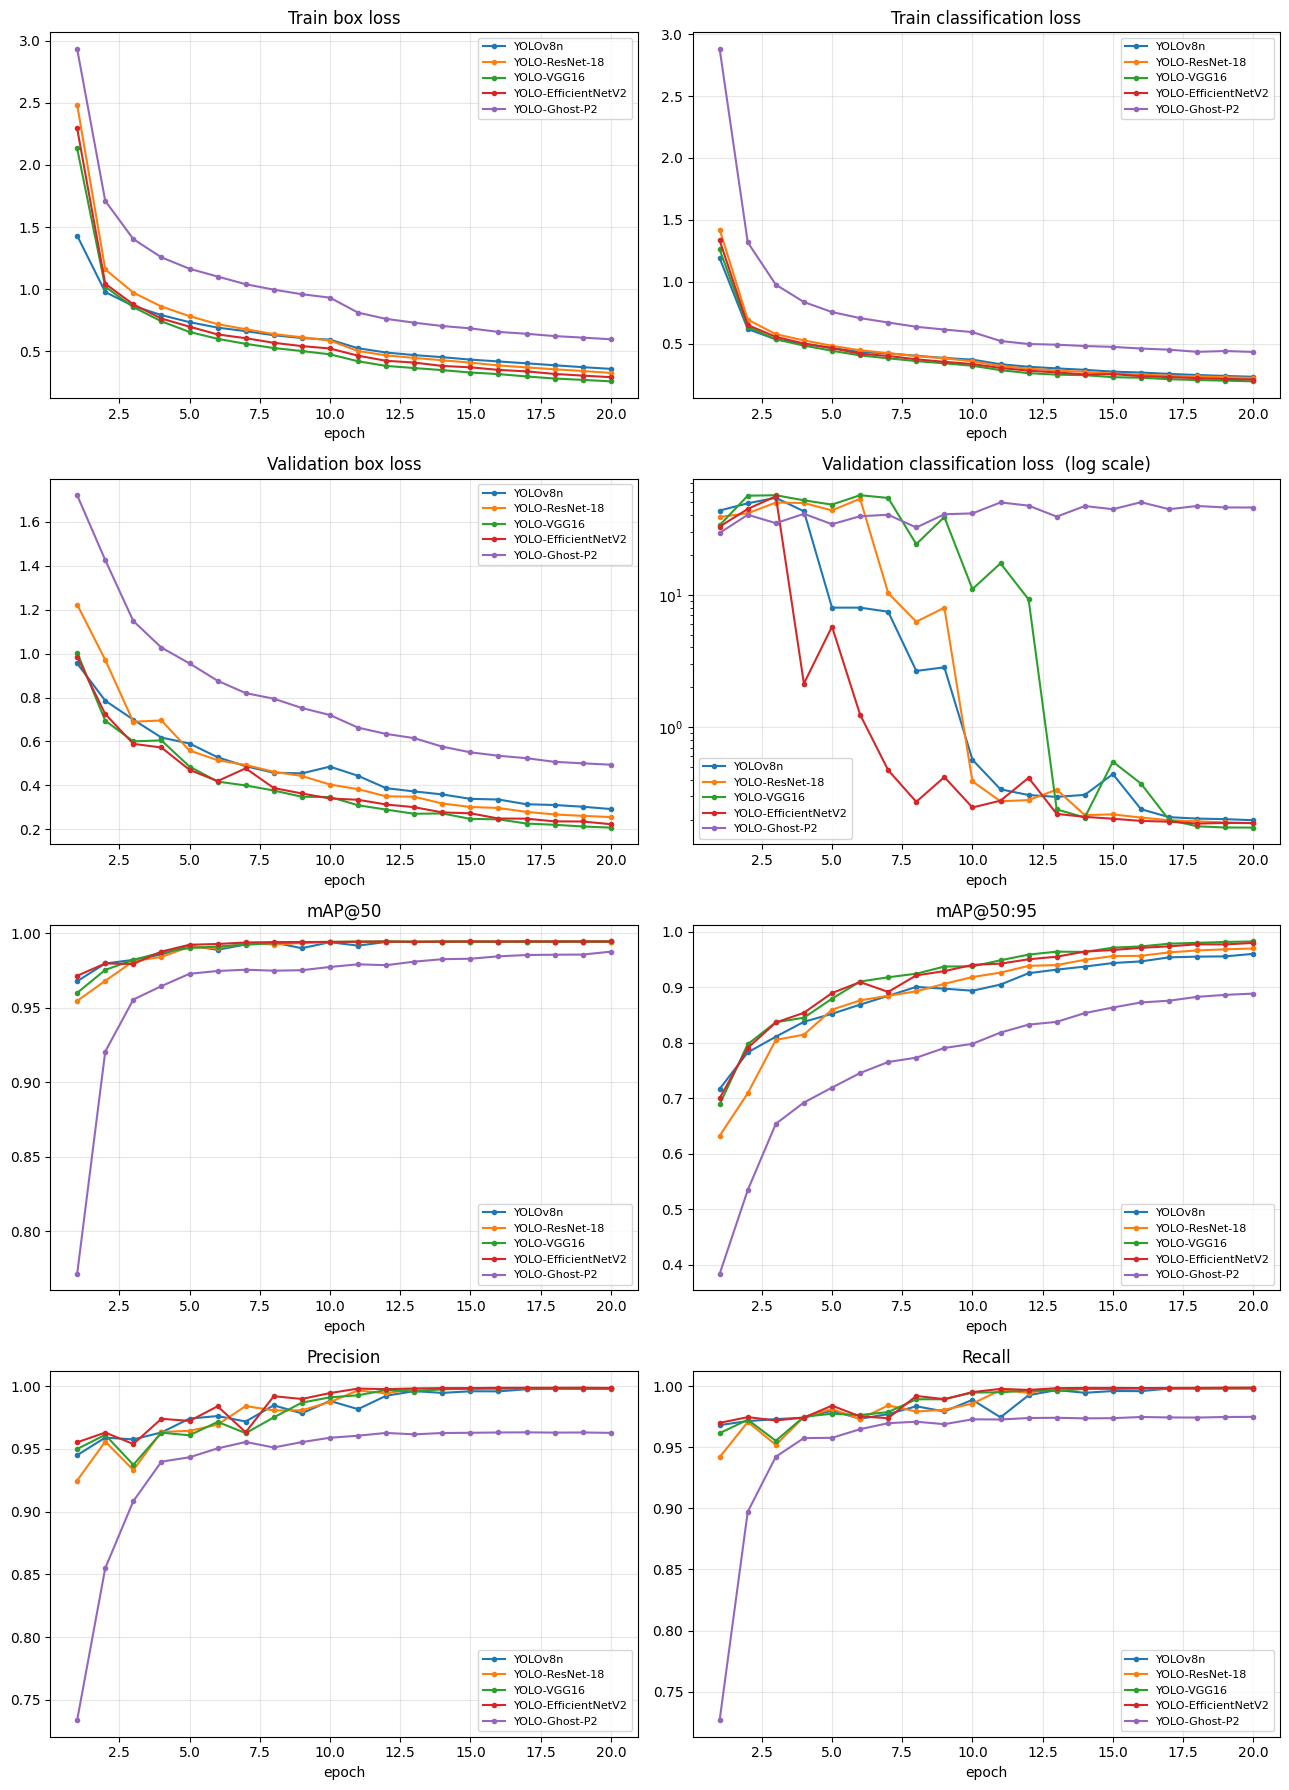

In [50]:
import matplotlib.pyplot as plt

METRICS = [("train/box_loss", "Train box loss"), ("train/cls_loss", "Train classification loss"),
           ("val/box_loss", "Validation box loss"), ("val/cls_loss", "Validation classification loss"),
           ("metrics/mAP50(B)", "mAP@50"), ("metrics/mAP50-95(B)", "mAP@50:95"),
           ("metrics/precision(B)", "Precision"), ("metrics/recall(B)", "Recall")]

curves = {}
for key in ALL_MODELS:
    csv = PROJECT / f"{key}_train" / "results.csv"
    if csv.exists():
        df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
        curves[DISPLAY_NAME[key]] = df

if not curves:
    print("no results.csv yet - train something first")
else:
    fig, axes = plt.subplots(4, 2, figsize=(13, 18))
    for ax, (col, title) in zip(axes.ravel(), METRICS):
        for label, df in curves.items():
            if col in df:
                ax.plot(df["epoch"], df[col], marker="o", ms=3, label=label)
        ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
        # Ghost-P2's val/cls_loss diverges to ~65 in the authors' logs, flattening everything else
        if col == "val/cls_loss":
            vals = [v for df in curves.values() if col in df for v in df[col]]
            if vals and max(vals) / max(min(vals), 1e-6) > 50:
                ax.set_yscale("log"); ax.set_title(title + "  (log scale)")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PROJECT / "comparison_plots.png", dpi=130, bbox_inches="tight")
    plt.show()

## 10 · Wrap up

Everything below `/kaggle/working/` becomes this version's **output** once the commit finishes —
download it from the notebook's Output tab, or attach it as an input to the next commit to
continue where you left off.

In [51]:
import subprocess

print("=== /kaggle/working ===")
print(subprocess.run(["du", "-sh", "/kaggle/working"], capture_output=True, text=True).stdout)

trained = [k for k in ALL_MODELS if (PROJECT / f"{k}_train" / "weights" / "best.pt").exists()]
missing = [k for k in ALL_MODELS if k not in trained]
print(f"trained : {trained}")
print(f"missing : {missing}")

if missing:
    print(f"\nNext commit: set  MODELS_TO_RUN = {missing}")
    print("Then: Add Input -> Notebook Output -> this notebook's finished version,")
    print("so Section 2 restores what you already have.")
else:
    print("\nAll five models trained. my_results.csv and comparison_vs_paper.csv are your "
          "deliverables - pair them with ml/PAPER_NOTES.md for the write-up.")

=== /kaggle/working ===
322M	/kaggle/working

trained : ['yolov8n', 'resnet18', 'vgg16', 'efficientnetv2', 'ghostp2']
missing : []

All five models trained. my_results.csv and comparison_vs_paper.csv are your deliverables - pair them with ml/PAPER_NOTES.md for the write-up.
